## Name : Sanjay Kumar
## Roll no : 24f-ai-020
## Project Name : Employee Attrition Analyzer

In [3]:
pip install kagglehub


   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   -------------------- ------------------- 1/2 [kagglehub]
   ---------------------------------------- 2/2 [kagglehub]

Note: you may need to restart the kernel to use updated packages.


In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("pavansubhasht/ibm-hr-analytics-attrition-dataset")

print("Path to dataset files:", path)

100%|██████████████████████████████████████████████████████████████████████████████| 50.1k/50.1k [00:00<00:00, 155kB/s]

Extracting files...
Path to dataset files: C:\Users\LENOVO\.cache\kagglehub\datasets\pavansubhasht\ibm-hr-analytics-attrition-dataset\versions\1


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)

In [28]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv", sep=",")

print("Dataset shape:", df.shape)
print("head________" , df.head())
print("\nMissing values:\n", df.isnull().sum().sum())
print("\nAttrition distribution:\n", df["Attrition"].value_counts())

Dataset shape: (1470, 35)
head________    Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction St

In [26]:
cols_to_remove = ["EmployeeCount", "Over18", "StandardHours", "EmployeeNumber"]
df = df.drop(columns=cols_to_remove)

In [27]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2


In [29]:
df = pd.get_dummies(df, drop_first=True)

In [31]:
df.head()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1102,1,2,1,1,2,94,3,2,...,False,False,False,False,False,True,False,False,True,True
1,49,279,8,1,1,2,3,61,2,2,...,False,False,False,False,True,False,False,True,False,False
2,37,1373,2,2,1,4,4,92,2,1,...,True,False,False,False,False,False,False,False,True,True
3,33,1392,3,4,1,5,4,56,3,1,...,False,False,False,False,True,False,False,True,False,True
4,27,591,2,1,1,7,1,40,3,1,...,True,False,False,False,False,False,False,True,False,False


In [32]:
X = df.drop("Attrition_Yes", axis=1)
y = df["Attrition_Yes"]

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [34]:
# Model 1: Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
lr_preds = lr_model.predict(X_test_scaled)

In [35]:
# Model 2: Decision Tree
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)
dt_preds = dt_model.predict(X_test)

In [36]:
# Model 3: Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

In [37]:
print("=== Model Performance ===")
print(
    f"Logistic Regression -> Accuracy: {accuracy_score(y_test, lr_preds):.2f}, F1: {f1_score(y_test, lr_preds):.2f}"
)
print(
    f"Decision Tree       -> Accuracy: {accuracy_score(y_test, dt_preds):.2f}, F1: {f1_score(y_test, dt_preds):.2f}"
)
print(
    f"Random Forest       -> Accuracy: {accuracy_score(y_test, rf_preds):.2f}, F1: {f1_score(y_test, rf_preds):.2f}"
)

=== Model Performance ===
Logistic Regression -> Accuracy: 0.88, F1: 0.51
Decision Tree       -> Accuracy: 0.82, F1: 0.19
Random Forest       -> Accuracy: 0.88, F1: 0.18


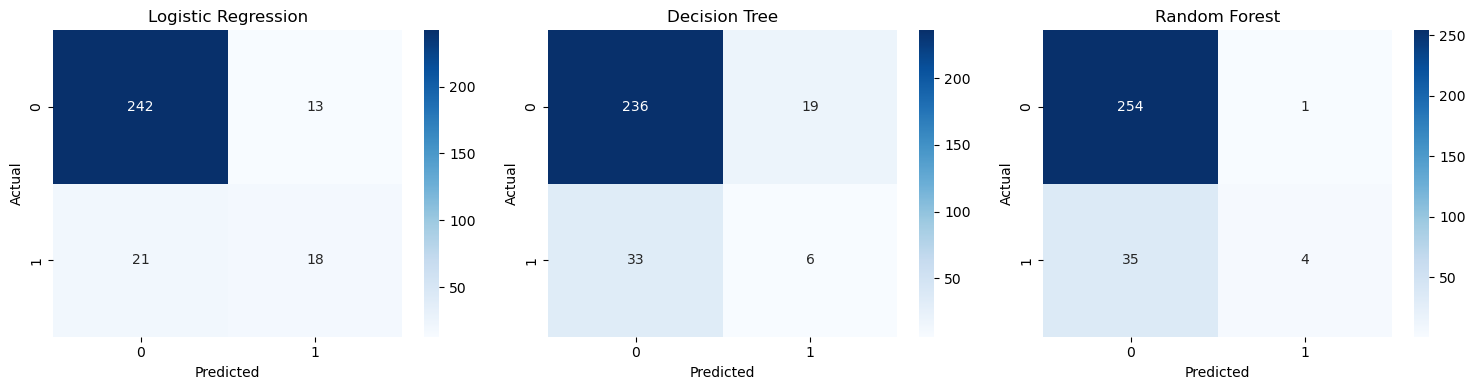

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Confusion Matrix for Logistic Regression
sns.heatmap(
    confusion_matrix(y_test, lr_preds),
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[0],
)
axes[0].set_title("Logistic Regression")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# Confusion Matrix for Decision Tree
sns.heatmap(
    confusion_matrix(y_test, dt_preds),
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[1],
)
axes[1].set_title("Decision Tree")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

# Confusion Matrix for Random Forest
sns.heatmap(
    confusion_matrix(y_test, rf_preds),
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[2],
)
axes[2].set_title("Random Forest")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Actual")

plt.tight_layout()
plt.show()

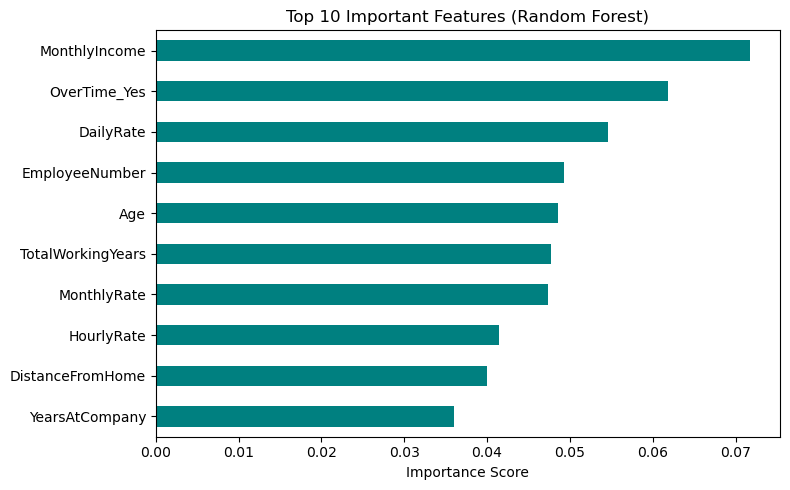

In [39]:
importance_series = pd.Series(rf_model.feature_importances_, index=X.columns)
top_10_features = importance_series.sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
top_10_features.plot(kind="barh", color="teal")
plt.title("Top 10 Important Features (Random Forest)")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()  # Put highest score on top
plt.tight_layout()
plt.show()